<a href="https://colab.research.google.com/github/bayatalireza/Deep-Learning/blob/main/Intro_to_DL_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -Uqq fastbook
import fastbook
#fastbook.setup_book() #mount GDrive
from fastbook import *
from matplotlib import pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.2 MB/s eta 0:00:00


In [6]:
path = untar_data(URLs.MNIST_SAMPLE)
path

Path('/root/.fastai/data/mnist_sample')

In [9]:
path.ls()


(#3) [Path('/root/.fastai/data/mnist_sample/labels.csv'),Path('/root/.fastai/data/mnist_sample/valid'),Path('/root/.fastai/data/mnist_sample/train')]

In [11]:
Path.BASE_PATH=path

In [12]:
path.ls()

(#3) [Path('labels.csv'),Path('valid'),Path('train')]

In [13]:
(path/"train").ls()

(#2) [Path('train/3'),Path('train/7')]

In [14]:
threes = (path/"train/3").ls().sorted()
sevens = (path/"train/7").ls().sorted()


In [15]:
threes
img3_path=threes[64]
img3= Image.open(img3_path)
img3

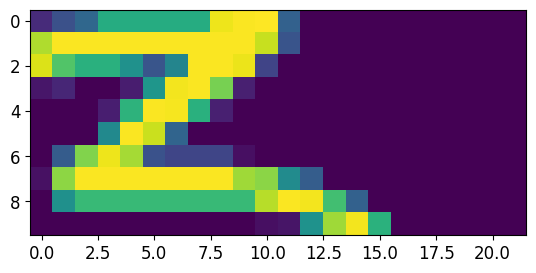

In [17]:
# we can convert PILImageFile to a numpy array or a tensor (on GPU):
im3_array = array(img3)
plt.imshow(im3_array)
im3_tensor = tensor( img3)
plt.imshow(im3_tensor[5:15, 6:28])


In [18]:
# We can also use pandas Df to vizualize them in a neat way:
df = pd.DataFrame(im3_array)
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,31,63,85,158,158,158,158,158,249,254,255,79,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,31,225,254,254,254,254,254,254,254,254,254,234,66,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,41,242,186,162,162,129,67,116,254,254,248,52,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,15,27,0,0,20,134,251,254,203,22,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,21,165,254,252,162,22,0,0,0,0,0,0,0,0,0,0,0,0,0


In [20]:
three_tensors = [tensor(Image.open(f)) for f in threes]
sevens_tensors = [tensor(Image.open(f)) for f in sevens]

<Axes: >

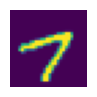

In [24]:
len(sevens_tensors)
sevens_tensors[12].shape
show_image(sevens_tensors[12])


In [25]:
stacked_threes = torch.stack(three_tensors).float()/255
stacked_sevens = torch.stack(sevens_tensors).float()/255


In [29]:
print(stacked_sevens.shape)
a_3 = stacked_threes[12]
a_3.shape

torch.Size([6265, 28, 28])


torch.Size([28, 28])

<Axes: >

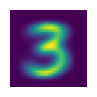

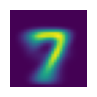

In [30]:
mean3 = stacked_threes.mean(0)
mean7 = stacked_sevens.mean(0)
show_image(mean3)
show_image(mean7)
#

In [31]:
def img_distance(a, b):
  return (a-b).abs().mean()

print(img_distance(a_3, mean3))
print(img_distance(a_3, mean7))


tensor(0.1286)
tensor(0.1534)


In [32]:
(path/"valid/3").ls()

(#1010) [Path('valid/3/2684.png'),Path('valid/3/883.png'),Path('valid/3/381.png'),Path('valid/3/8290.png'),Path('valid/3/5573.png'),Path('valid/3/6432.png'),Path('valid/3/808.png'),Path('valid/3/9840.png'),Path('valid/3/1489.png'),Path('valid/3/3659.png'),Path('valid/3/3261.png'),Path('valid/3/2723.png'),Path('valid/3/9468.png'),Path('valid/3/8811.png'),Path('valid/3/8551.png'),Path('valid/3/9561.png'),Path('valid/3/9125.png'),Path('valid/3/3769.png'),Path('valid/3/3484.png'),Path('valid/3/2632.png')...]

In [34]:
#Stack tensors:
valid_3_tensors = torch.stack([tensor(Image.open(f)) for f in (path/'valid/3').ls()])
valid_7_tensors = torch.stack([tensor(Image.open(f)) for f in (path/'valid/7').ls()])

#Normalize tensors:
valid_3_tensors = valid_3_tensors.float()/255
valid_7_tensors = valid_7_tensors.float()/255

print(valid_3_tensors.shape)
print(valid_7_tensors.shape)

torch.Size([1010, 28, 28])
torch.Size([1028, 28, 28])


In [49]:
def img_distance(input, mean_tensor):
  return (input - mean_tensor).abs().mean((-1, -2))


def is_3(x):
  return (img_distance(x, mean3) < img_distance(x, mean7)).float()

In [50]:
is_3(valid_3_tensors).shape

torch.Size([1010])

In [52]:
accuracy_3 = is_3(valid_3_tensors).mean()
accuracy_7 = (1 - is_3(valid_7_tensors)).mean()
print(accuracy_3)
print(accuracy_7)



tensor(0.9168)
tensor(0.9854)
